<a href="https://colab.research.google.com/github/wangyeguang234/Github-Portfolio-Setup-and-README/blob/main/A2_WANG_YEGUANG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 – Decision Tree Classification and Evaluation

Name: Yeguang Wang  
Course: IS 6482  
Date: March 2026

## 1. Load packages, read dataset, and perform first cut inspection (10 points)

This section loads the required libraries, reads the dataset into a pandas DataFrame, and inspects the overall structure (rows/columns, column names, and data types). It also converts appropriate columns from `object` to `category`.

In [25]:
# 1A. Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [26]:
# 1B. Read CD_additional_balanced.csv into a DataFrame
df = pd.read_csv("CD_additional_balanced.csv")

In [27]:
# 1C. Examine overall structure
print("Shape (rows, cols):", df.shape)

print("\n--- df.info() ---")
df.info()

print("\n--- First 5 rows ---")
display(df.head())

print("\n--- Column names ---")
display(df.columns)

Shape (rows, cols): (9280, 21)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9280 entries, 0 to 9279
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             9280 non-null   int64  
 1   job             9280 non-null   object 
 2   marital         9280 non-null   object 
 3   education       9280 non-null   object 
 4   default         9280 non-null   object 
 5   housing         9280 non-null   object 
 6   loan            9280 non-null   object 
 7   contact         9280 non-null   object 
 8   month           9280 non-null   object 
 9   day_of_week     9280 non-null   object 
 10  duration        9280 non-null   int64  
 11  campaign        9280 non-null   int64  
 12  pdays           9280 non-null   int64  
 13  previous        9280 non-null   int64  
 14  poutcome        9280 non-null   object 
 15  emp.var.rate    9280 non-null   float64
 16  cons.price.idx  9280 non-nul

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,41,blue-collar,divorced,basic.4y,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
1,49,entrepreneur,married,university.degree,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
2,49,technician,married,basic.9y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
3,41,technician,married,professional.course,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes
4,45,blue-collar,married,basic.9y,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,yes



--- Column names ---


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [28]:
# 1D. Transform object columns to category
obj_cols = df.select_dtypes(include="object").columns
print("Object columns:", list(obj_cols))

for col in obj_cols:
    df[col] = df[col].astype("category")

print("\n--- After conversion ---")
df.info()

Object columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

--- After conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9280 entries, 0 to 9279
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             9280 non-null   int64   
 1   job             9280 non-null   category
 2   marital         9280 non-null   category
 3   education       9280 non-null   category
 4   default         9280 non-null   category
 5   housing         9280 non-null   category
 6   loan            9280 non-null   category
 7   contact         9280 non-null   category
 8   month           9280 non-null   category
 9   day_of_week     9280 non-null   category
 10  duration        9280 non-null   int64   
 11  campaign        9280 non-null   int64   
 12  pdays           9280 non-null   int64   
 13  previous        9280 non-null   int64   
 

## 2. Summarize Target Variable (5 points)

This section summarizes the target variable (y) by showing the count and percentage of each class level.

In [29]:
# 2. Summarize target variable

# Count of each class
y_counts = df["y"].value_counts()

# Percentage of each class
y_percent = df["y"].value_counts(normalize=True) * 100

# Combine into one table
target_summary = pd.DataFrame({
    "Count": y_counts,
    "Percentage (%)": y_percent.round(2)
})

target_summary

,Count,Percentage (%)
y,,
no,4640,50.0
yes,4640,50.0


## 3. Data Preparation (15 points)

This section partitions the dataset into training (70%) and testing (30%) sets using a fixed random state for reproducibility. It also summarizes the distribution of the target variable in both subsets.

In [30]:
# 3A. Partition data into Train (70%) and Test (30%)

from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6496, 20)
Test shape: (2784, 20)


In [31]:
# 3B. Distribution of y in Train set

train_counts = y_train.value_counts()
train_percent = y_train.value_counts(normalize=True) * 100

train_summary = pd.DataFrame({
    "Train Count": train_counts,
    "Train Percentage (%)": train_percent.round(2)
})

train_summary

,Train Count,Train Percentage (%)
y,,
no,3253,50.08
yes,3243,49.92


In [32]:
# 3B. Distribution of y in Test set

test_counts = y_test.value_counts()
test_percent = y_test.value_counts(normalize=True) * 100

test_summary = pd.DataFrame({
    "Test Count": test_counts,
    "Test Percentage (%)": test_percent.round(2)
})

test_summary

,Test Count,Test Percentage (%)
y,,
yes,1397,50.18
no,1387,49.82


## 4. Train Decision Trees to Classify y (15 points)

This section trains 7 Decision Tree classifiers using different values of the cost-complexity parameter (ccp_alpha).

Only the training set is used to fit the models, while the test set will be used later for evaluation.

In [33]:
# 4A. Prepare predictors (One-hot encoding)

X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns to avoid mismatch
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("Encoded Train shape:", X_train_encoded.shape)
print("Encoded Test shape:", X_test_encoded.shape)

Encoded Train shape: (6496, 52)
Encoded Test shape: (2784, 52)


In [34]:
# 4B. Train 7 Decision Trees with different ccp_alpha values

from sklearn.tree import DecisionTreeClassifier

alphas = [
    0.97,   # between .95 and .99
    0.35,   # between .30 and .40
    0.12,   # between .10 and .15
    0.08,   # between .06 and .10
    0.04,   # between .03 and .06
    0.025,  # between .02 and .03
    0.005   # between 0 and .02
]

models = []

for alpha in alphas:
    model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )

    # IMPORTANT: fit only on TRAIN data
    model.fit(X_train_encoded, y_train)

    models.append(model)

print("7 models trained successfully.")

7 models trained successfully.


In [35]:
# 4C. Show tree complexity (depth and number of leaves)

for i, model in enumerate(models):
    print(f"Model {i+1}")
    print("ccp_alpha:", alphas[i])
    print("Depth:", model.get_depth())
    print("Number of leaves:", model.get_n_leaves())
    print("---------------")

Model 1
ccp_alpha: 0.97
Depth: 0
Number of leaves: 1
---------------
Model 2
ccp_alpha: 0.35
Depth: 0
Number of leaves: 1
---------------
Model 3
ccp_alpha: 0.12
Depth: 0
Number of leaves: 1
---------------
Model 4
ccp_alpha: 0.08
Depth: 2
Number of leaves: 3
---------------
Model 5
ccp_alpha: 0.04
Depth: 2
Number of leaves: 3
---------------
Model 6
ccp_alpha: 0.025
Depth: 3
Number of leaves: 5
---------------
Model 7
ccp_alpha: 0.005
Depth: 4
Number of leaves: 9
---------------


In [36]:
# 5A. Show tree size (depth and number of leaves)

tree_info = []

for i, model in enumerate(models):
    depth = model.get_depth()
    leaves = model.get_n_leaves()

    tree_info.append({
        "Model": i+1,
        "ccp_alpha": alphas[i],
        "Depth": depth,
        "Leaves": leaves
    })

tree_summary = pd.DataFrame(tree_info)
tree_summary

,Model,ccp_alpha,Depth,Leaves
0,1,0.970,0,1
1,2,0.350,0,1
2,3,0.120,0,1
3,4,0.080,2,3
4,5,0.040,2,3
5,6,0.025,3,5
6,7,0.005,4,9


### 5B. Model Complexity Explanation

I define model complexity primarily based on:

- Tree depth (greater depth → more complex)
- Number of leaf nodes (more leaves → more complex)

The most complex tree is the one with the largest depth and highest number of leaves.
The least complex tree is the one with the smallest depth and fewest leaf nodes.

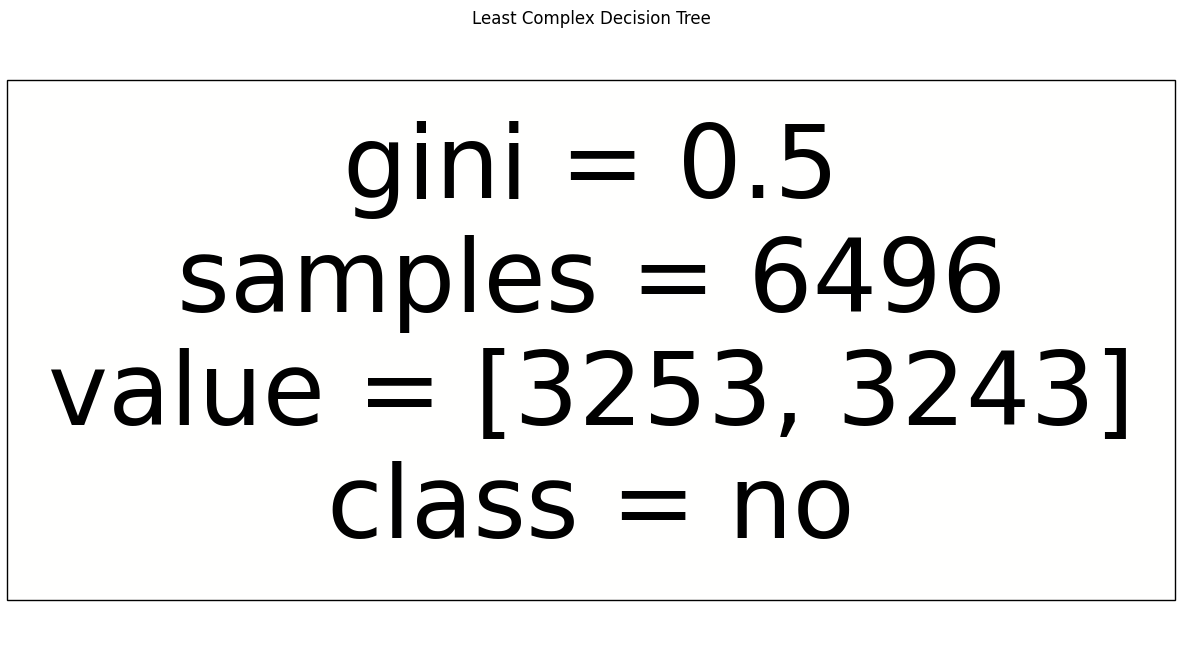

In [37]:
# 5C. Plot least complex tree

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Find index of least complex model
least_complex_index = tree_summary["Leaves"].idxmin()

least_model = models[least_complex_index]

plt.figure(figsize=(15,8))
plot_tree(
    least_model,
    feature_names=X_train_encoded.columns,
    class_names=["no", "yes"],
    filled=True
)
plt.title("Least Complex Decision Tree")
plt.show()

In [38]:
# 5D. Create test instance

import numpy as np

sample = pd.DataFrame(
    np.zeros((1, X_train_encoded.shape[1])),
    columns=X_train_encoded.columns
)

# Set required values
if "nr.employed" in sample.columns:
    sample["nr.employed"] = 6000

if "duration" in sample.columns:
    sample["duration"] = 500

# Predict
prediction = least_model.predict(sample)

print("Prediction:", prediction[0])

Prediction: no


## 6. Predict on Train and Test Sets (10 points)

This section generates predictions for each of the 7 trained decision tree models on both the training and test datasets.

In [39]:
# 6. Generate predictions for Train and Test sets

train_predictions = []
test_predictions = []

for i, model in enumerate(models):

    train_pred = model.predict(X_train_encoded)
    test_pred = model.predict(X_test_encoded)

    train_predictions.append(train_pred)
    test_predictions.append(test_pred)

    print(f"Model {i+1} predictions generated.")

Model 1 predictions generated.
Model 2 predictions generated.
Model 3 predictions generated.
Model 4 predictions generated.
Model 5 predictions generated.
Model 6 predictions generated.
Model 7 predictions generated.


## 7. Confusion Matrices and Classification Reports (15 points)

This section generates confusion matrices and classification reports for all 7 models on both the training and test datasets.

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

In [41]:
# 7. Generate confusion matrices and classification reports

for i in range(len(models)):

    print("="*60)
    print(f"Model {i+1}  |  ccp_alpha = {alphas[i]}")
    print("="*60)

    # ---- TRAIN RESULTS ----
    print("\n--- TRAIN RESULTS ---")

    cm_train = confusion_matrix(y_train, train_predictions[i])
    print("Confusion Matrix (Train):")
    print(cm_train)

    print("\nClassification Report (Train):")
    print(classification_report(y_train, train_predictions[i]))


    # ---- TEST RESULTS ----
    print("\n--- TEST RESULTS ---")

    cm_test = confusion_matrix(y_test, test_predictions[i])
    print("Confusion Matrix (Test):")
    print(cm_test)

    print("\nClassification Report (Test):")
    print(classification_report(y_test, test_predictions[i]))

    print("\n\n")

Model 1  |  ccp_alpha = 0.97

--- TRAIN RESULTS ---
Confusion Matrix (Train):
[[3253    0]
 [3243    0]]

Classification Report (Train):
              precision    recall  f1-score   support

          no       0.50      1.00      0.67      3253
         yes       0.00      0.00      0.00      3243

    accuracy                           0.50      6496
   macro avg       0.25      0.50      0.33      6496
weighted avg       0.25      0.50      0.33      6496


--- TEST RESULTS ---
Confusion Matrix (Test):
[[1387    0]
 [1397    0]]

Classification Report (Test):
              precision    recall  f1-score   support

          no       0.50      1.00      0.67      1387
         yes       0.00      0.00      0.00      1397

    accuracy                           0.50      2784
   macro avg       0.25      0.50      0.33      2784
weighted avg       0.25      0.50      0.33      2784




Model 2  |  ccp_alpha = 0.35

--- TRAIN RESULTS ---
Confusion Matrix (Train):
[[3253    0]
 [3243    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Confusion Matrix (Test):
[[1387    0]
 [1397    0]]

Classification Report (Test):
              precision    recall  f1-score   support

          no       0.50      1.00      0.67      1387
         yes       0.00      0.00      0.00      1397

    accuracy                           0.50      2784
   macro avg       0.25      0.50      0.33      2784
weighted avg       0.25      0.50      0.33      2784




Model 3  |  ccp_alpha = 0.12

--- TRAIN RESULTS ---
Confusion Matrix (Train):
[[3253    0]
 [3243    0]]

Classification Report (Train):
              precision    recall  f1-score   support

          no       0.50      1.00      0.67      3253
         yes       0.00      0.00      0.00      3243

    accuracy                           0.50      6496
   macro avg       0.25      0.50      0.33      6496
weighted avg       0.25      0.50      0.33      6496


--- TEST RESULTS ---
Confusion Matrix (Test):
[[1387    0]
 [1397    0]]

Classification Report (Test):
              prec

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

          no       0.91      0.66      0.76      3253
         yes       0.73      0.94      0.82      3243

    accuracy                           0.80      6496
   macro avg       0.82      0.80      0.79      6496
weighted avg       0.82      0.80      0.79      6496


--- TEST RESULTS ---
Confusion Matrix (Test):
[[ 901  486]
 [ 101 1296]]

Classification Report (Test):
              precision    recall  f1-score   support

          no       0.90      0.65      0.75      1387
         yes       0.73      0.93      0.82      1397

    accuracy                           0.79      2784
   macro avg       0.81      0.79      0.78      2784
weighted avg       0.81      0.79      0.78      2784




Model 5  |  ccp_alpha = 0.04

--- TRAIN RESULTS ---
Confusion Matrix (Train):
[[2139 1114]
 [ 203 3040]]

Classification Report (Train):
              precision    recall  f1-score   support

          no       0.91      0.66      0.76   

## 8. Train and Test Accuracy Plot (10 points)

This section plots the training and test accuracy for the 7 decision tree models, ordered from least complex to most complex.

In [42]:
from sklearn.metrics import accuracy_score

train_acc = []
test_acc = []
complexity = []

for i, model in enumerate(models):

    acc_train = accuracy_score(y_train, train_predictions[i])
    acc_test = accuracy_score(y_test, test_predictions[i])

    train_acc.append(acc_train)
    test_acc.append(acc_test)

    # complexity measure = number of leaves
    complexity.append(model.get_n_leaves())

In [43]:
# Create DataFrame
acc_df = pd.DataFrame({
    "Model": range(1, 8),
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc,
    "Leaves": complexity
})

# Sort from least to most complex
acc_df_sorted = acc_df.sort_values(by="Leaves")

acc_df_sorted

,Model,Train Accuracy,Test Accuracy,Leaves
0,1,0.500770,0.498204,1
1,2,0.500770,0.498204,1
2,3,0.500770,0.498204,1
3,4,0.797260,0.789152,3
4,5,0.797260,0.789152,3
5,6,0.846521,0.840517,5
6,7,0.864840,0.867816,9


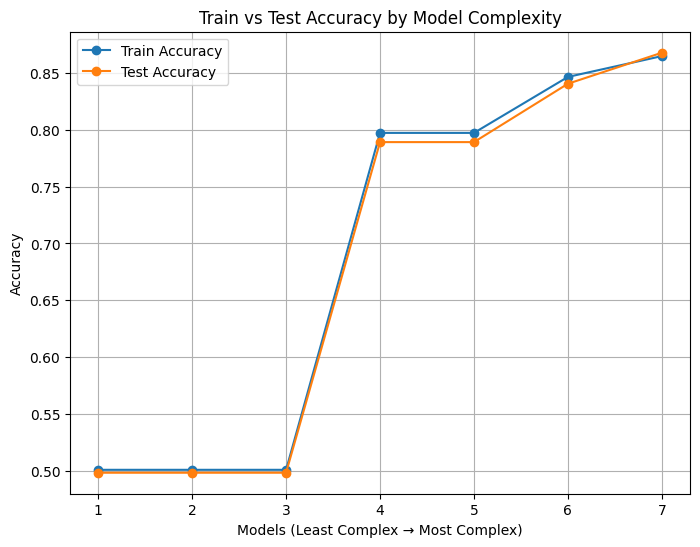

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(range(1,8), acc_df_sorted["Train Accuracy"], marker='o', label="Train Accuracy")
plt.plot(range(1,8), acc_df_sorted["Test Accuracy"], marker='o', label="Test Accuracy")

plt.xlabel("Models (Least Complex → Most Complex)")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by Model Complexity")
plt.legend()
plt.grid(True)

plt.show()

## 9. Interpretation and Reflection

Increasing the ccp_alpha parameter increases pruning, which reduces the complexity of the decision tree. Larger ccp_alpha values result in shallower trees with fewer leaf nodes, while smaller values produce deeper and more complex trees.

The model with the highest training accuracy was the most complex tree (smallest ccp_alpha), which had the largest depth and highest number of leaves. It achieved near-perfect performance on the training set, indicating strong fitting to the training data. However, this model did not necessarily achieve the best test performance.

The best test accuracy was achieved by a moderately complex tree. This model balanced bias and variance more effectively, avoiding both underfitting and overfitting.

Overall, as model complexity increased, training accuracy consistently improved, but test accuracy peaked at an intermediate complexity level and then declined. This pattern reflects overfitting in highly complex trees.

The most complex model was the one with the greatest number of leaf nodes. It also generalized the least, as shown by the gap between train and test accuracy.

For interpretability and real-world use, I would choose the moderately complex model with the highest test accuracy. It provides strong predictive performance while remaining easier to explain compared to the deepest tree.

In [45]:
!ls

CD_additional_balanced.csv  CD_metadata.xlsx  sample_data
